# Retrieval, Method 1: Matrix Factorization (implicit ALS)

**Recap:** we're in the *retrieval* stage — cheaply narrowing the whole catalog down to a
shortlist of plausible items for a user. The classic, still-very-strong approach is
**matrix factorization**: represent every user and every item as a vector in a shared
latent space of dimension `f`, and score a [user(u), item(i)] pair with a simple dot product.

$$\hat{r}_{ui} = x_u \cdot y_i$$

If two items tend to be liked by the same users, ALS will push their vectors $y_i$ close
together — *without ever being told what a "genre" is*. That's the whole idea of learning
embeddings from interaction data.

## Why not plain SVD?

Classic matrix factorization (SVD-style) is built for **explicit** feedback (1-5 star
ratings) where missing entries are just... missing, and you only optimize over the
entries you observed.

With **implicit** feedback we don't have that luxury: "no interaction" doesn't mean
"neutral", it's ambiguous (dislike vs. never-seen). Hu, Koren & Volinsky (2008) proposed
the fix used almost everywhere today:

- Treat **every** (user, item) pair as a training example, not just observed ones.
- Turn the interaction into a **binary preference** $p_{ui} \in \{0, 1\}$ (1 if interacted).
- Attach a **confidence** $c_{ui} = 1 + \alpha \cdot r_{ui}$ ($r_{ui}$ = interaction
  count, in this case it wont be higher than 1, just 0 if interacted, or 1 otherwise). Observed interactions get high confidence; everything else gets
  confidence 1 — "probably negative, but we're not very sure".

The loss becomes a *confidence-weighted* least squares problem:

$$\min_{x_*, y_*} \sum_{u,i} c_{ui}\,(p_{ui} - x_u \cdot y_i)^2 \;+\; \lambda \Big(\sum_u \|x_u\|^2 + \sum_i \|y_i\|^2\Big)$$

This isn't jointly convex in $X$ and $Y$, but it's a simple ridge regression in $X$ if you
fix $Y$ (and vice versa) — hence **Alternating Least Squares**.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

import rec_utils as ru

ru.setup_plot_style()

interactions, user_prefs, item_genres, item_pop = ru.generate_synthetic_data()
train, test = ru.leave_one_out_split(interactions)

n_users = interactions.user_id.max() + 1
n_items = interactions.item_id.max() + 1
seen = ru.user_seen_items(train)
user_items, item_users = ru.user_item_lists(train)

print(f"{n_users} users, {n_items} items, {len(train)} train interactions")

600 users, 400 items, 14400 train interactions


## Implementing ALS

For a fixed item matrix $Y$, the optimal $x_u$ has a closed form (it's ridge regression):

$$x_u = \big(Y^\top C_u Y + \lambda I\big)^{-1} Y^\top C_u p_u$$

Computing $Y^\top C_u Y$ naively means an `(n_items, f) x (n_items, f)` product *for every
user* — way too slow. The key trick: $C_u$ is the identity almost everywhere (confidence 1
for every unobserved item), so

$$Y^\top C_u Y = Y^\top Y + Y^\top (C_u - I) Y$$

and $(C_u - I)$ is **zero except at the handful of items the user actually interacted
with**. So we precompute $Y^\top Y$ once per iteration, and each user's update only touches
their own (small) set of observed items. The item-side update is symmetric.

In [2]:
def train_als(user_items, item_users, n_users, n_items,
              f=16, alpha=5.0, reg=0.05, n_iters=15, seed=0):
    # f = number of latent factors (in movies this latent factor could be interpreted as "genre" or "style")
    # alpha = confidence weight for observed interactions (higher alpha means more confidence in observed interactions)
    # reg = regularization parameter (to prevent overfitting)
    # n_iters = number of iterations for the ALS algorithm, since it alternates between fixing user and item embeddings
    
    rng = np.random.default_rng(seed)
    X = rng.normal(0, 0.1, size=(n_users, f))   # user embeddings
    Y = rng.normal(0, 0.1, size=(n_items, f))   # item embeddings
    I_f = np.eye(f)
    loss_history = []

    for _ in range(n_iters):
        # --- fix Y, solve for every user's row ---
        YtY = Y.T @ Y
        for u in range(n_users):
            items = user_items.get(u, [])
            if not items:
                continue
            Yu = Y[items]                                   # (n_obs, f)
            A = YtY + alpha * (Yu.T @ Yu) + reg * I_f
            b = (1 + alpha) * Yu.sum(axis=0)
            X[u] = np.linalg.solve(A, b)

        # --- fix X, solve for every item's row ---
        XtX = X.T @ X
        for i in range(n_items):
            users = item_users.get(i, [])
            if not users:
                continue
            Xi = X[users]
            A = XtX + alpha * (Xi.T @ Xi) + reg * I_f
            b = (1 + alpha) * Xi.sum(axis=0)
            Y[i] = np.linalg.solve(A, b)

        # confidence-weighted reconstruction loss, for a training curve
        pred = X @ Y.T
        p = np.zeros((n_users, n_items))
        for u, items in user_items.items():
            p[u, items] = 1.0
        c = 1.0 + alpha * p
        loss = np.sum(c * (p - pred) ** 2) + reg * (np.sum(X**2) + np.sum(Y**2))
        loss_history.append(loss)

    return X, Y, loss_history


X, Y, loss_history = train_als(user_items, item_users, n_users, n_items)

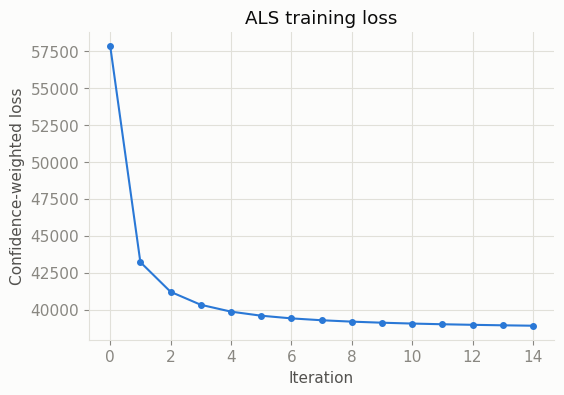

In [3]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(loss_history, color=ru.SEQUENTIAL_BLUE[3], marker="o", markersize=4)
ax.set_title("ALS training loss")
ax.set_xlabel("Iteration")
ax.set_ylabel("Confidence-weighted loss")
plt.show()

## Sanity check: did ALS recover the genre structure?

ALS never saw `item_genres` — it only saw which users interacted with which items. If the
learned item embeddings are meaningful, items that share a dominant genre should still end
up close together in embedding space, purely because they tend to be watched by the same
kind of user. Let's project the 16-D item embeddings down to 2D with PCA and color by
each item's *true* dominant genre (ground truth, used here only for this plot).

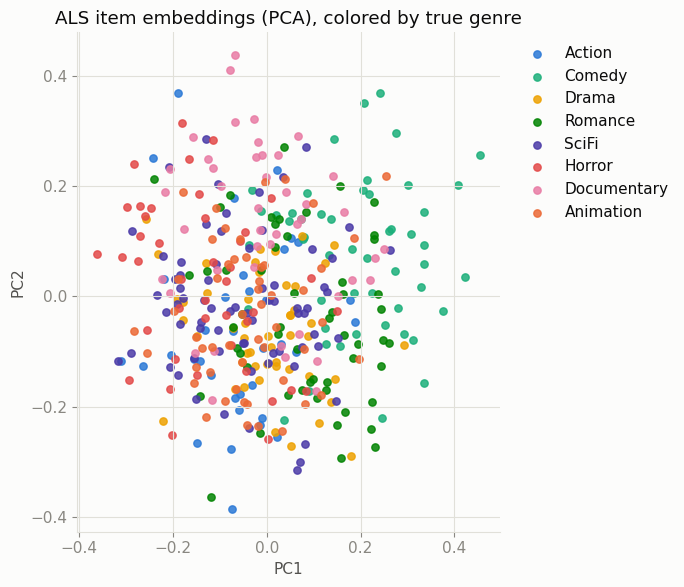

In [4]:
dominant_genre = item_genres.argmax(axis=1)
coords = PCA(n_components=2, random_state=0).fit_transform(Y)

fig, ax = plt.subplots(figsize=(7, 6))
for g in range(ru.N_GENRES):
    mask = dominant_genre == g
    ax.scatter(coords[mask, 0], coords[mask, 1], s=28,
               color=ru.GENRE_COLORS[g], label=ru.GENRE_NAMES[g], alpha=0.85)
ax.set_title("ALS item embeddings (PCA), colored by true genre")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
fig.tight_layout()
plt.show()

In [5]:
# do it in pca with 3 components and plot in 3D
coords_3d = PCA(n_components=3, random_state=0).fit_transform(Y)

# make the 3D plot interactive
import plotly.express as px
fig = px.scatter_3d(
    x=coords_3d[:, 0], y=coords_3d[:, 1], z=coords_3d[:, 2],
    color=[ru.GENRE_NAMES[g] for g in dominant_genre],
    color_discrete_sequence=ru.GENRE_COLORS,
    labels={"x": "PC1", "y": "PC2", "z": "PC3"},
    title="ALS item embeddings (PCA 3D), colored by true genre"
)
fig.update_traces(marker=dict(size=4, opacity=0.85))
fig.show()

You should see visible (if imperfect) genre clusters — evidence that ALS is picking up
real taste structure from co-occurrence alone, not just popularity.

## From embeddings to recommendations

Scoring every item for a user is now a single dot product: `X[u] @ Y.T`. We rank all
items by that score and drop anything the user has already interacted with.

In [6]:
# the top 10 recommendations for user 0
np.argsort(X[0] @ Y.T)[::-1][:10]

array([342, 177, 147, 259, 387, 100, 363, 153, 319, 136], dtype=int64)

In [7]:
def recommend_als(user_id, n):
    scores = X[user_id] @ Y.T
    return ru.rank_topn(scores, seen.get(user_id, set()), n)

metrics = ru.evaluate_recommender(recommend_als, train, test, k_list=(10, 20))
ru.save_results("01_als", metrics)

results_so_far = ru.load_all_results()
pd.DataFrame(results_so_far).T

Saved results to D:\Pablo_Data\Documentos\VSCode\revolut\recommendation_algorithms\results\01_als.json


,recall@10,ndcg@10,recall@20,ndcg@20
00_popularity,0.051667,0.029234,0.085000,0.037774
01_als,0.108333,0.062281,0.168333,0.077169
02_item2vec,0.121667,0.055420,0.176667,0.069363
03_gbdt_ranking,0.115000,0.060645,0.193333,0.080500
04_two_tower,0.095000,0.051513,0.163333,0.068416


## Takeaways

- ALS turns implicit feedback into a confidence-weighted regression problem with a clean
  closed-form alternating solver — no gradient descent, no learning rate to tune.
- It clearly beats the popularity baseline from notebook 00, and the PCA plot shows *why*:
  it recovers real taste structure.
- Limitations: pure **cold start** for new users/items (no interactions yet -> no
  embedding), and it only ever looks at the user-item matrix — no side information (item
  metadata, user features) unless you extend the model.

Next: `02_retrieval_embedding_similarity.ipynb` learns *item-only* embeddings from
co-occurrence (skip-gram style) and builds a user vector on the fly by averaging —
a different, more flexible way to get to the same retrieval goal.